# Section Notes #1: Basic Incomplete Markets Models in GE

Het Agent Macro. Professor  **Ludwig Straub** [ludwigstraub@fas.harvard.edu], Teaching Fellow **Martin Aragoneses** [maragoneses@g.harvard.edu]

**Preliminaries** *T.F.* Sections* Mon 8:30-9:30AM ET. *Problem Set 1* is due by EOD this Friday (NOT Thu @ class anymore)
- Today we cover how to get started in solving one of these models with Python, which you need to do in question 2. 
- Of course, it's totally OK if you want to ignore my/Ludwig's code and try to code up this problem set on your own (in principle, you could even use a different programming language).
- However, starting next week, you will have to use Python to make use of the tools that have been developed to implement Sequence-Space Jacobian methods efficiently (coding and debugging this up from scratch in Julia/MATLAB/... would take you a lot more time than you have for this course and prevent you from learning the economics). Hence, we recommend solving this problem set in Python -- this will help you learn how to use some of the Python modules we will use intensively starting next week, which you will need to be able to do the 4 PSETs on time (recall we have a PSET due almost weekly!).
- If you are stuck on the numerical methods, I found really useful the materials I learned in this class taught by Jesus Fernandez-Villaverde when he visited Harvard. The materials are all here: https://www.sas.upenn.edu/~jesusfv/teaching.html 

**What I will give you** I will be giving you **first some code you get you started**, and **later pseudo-code to help you with problem sets as a template** if you need it, although we really recommend starting from scratch to really learn. It's OK if you struggle a bit and can't do everything as if you were a master Python coder (which we are not!): we won't penalize you! We just want you to learn some nice tools. Also, all this was written on the fly since it's the first time we are teaching this course, so we can't promise there won't be any bugs or errors; use with a grain of salt. 

**Section Outline** Today, we will cover the following:

1. **Parametrization & discretization** of continuous exogenous and endogenous variables on finite grids; making sure we are not violating the **natural borrowing limit**.

2. **Backward iteration** to solve policy functions $x_t$ by backward induction on the household's Bellman or related object from a terminal steady state $V_T$

3. **Forward iteration** to iterates the distribution forward using the path of policies from initial steady state $D_0$. In particular, how to think of off-grid distribution transitions as a stochastic process.

4. **Aggregation** over over the sequence of equilibrium policies and distributions

5. **Steady State** found via fixed point/root finding algorithm by iterating policies backward and the distribution forward until convergence, given endogenous aggregates are fixed over time

6. **IRF** exploiting perfect-foresight after an MIT shock found via a bisection-based shooting algorithm 

**Important** If you manage to learn how to do 1-5 but you can't do 6, it's OK! Shooting algorithms are hard and unreliable. We'll be learning "easier" but clever alternatives throughout the course that use sequence-space Jacobians rather than ad-hoc rules.

PS. If you get stuck playing with ODEs in question 1, I can send you some example materials. 


## Krusell-Smith/Aiyagari Model



Let's go back to our Neoclassical Growth Model where households have inelastic labor supply. Here, however, they experience exogenous labor supply quality shocks affecting their individual earnings but not the aggregate directly (make $E\{s\}=L=1$).

$$
\begin{align}
V_t(s, a_{-}) = \max_{c, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} + \beta \: \mathbb{E}_{s'|s}V_{t+1}(s', a)  \right\}
\\
c + a &= (1 + r_{t-1})a_{-} + w_t s, \quad s \sim \{0,1\}  \\ 
a &\geq \underline{a} =0
\end{align}
$$

Solving this problem delivers policies ${c=c_{t}^{*}\left(s,a_{-}\right)},{a=a_{t}^{*}\left(s,a_{-}\right)}$. Since ${a=a_{t}^{*}\left(s,a_{-}\right)}\ge 0$, nobody can borrow in equilibrium, where does the supply of household's savings go? Into investing in *physical capital*, which is demanded  as an input in production. A competitive firm makes zero profits and rents capital one period in advance.

$$ Y_t = Z_{t} K_{t-1}^{\alpha} L_{t}^{1-\alpha}, \quad D_{t} = Y_{t} - w_{t}L_{t} - r_{t-1}^k K_{t-1} = 0$$

Since labor supply is completely inelastic $L=1$, $w$ are pinned down by labor demand from firms 

$$ w_{t}	= (1-\alpha)Z_{t}\left(K_{t-1}\right)^{\alpha},\quad r_{t-1}^{k}=r_{t-1} + \delta = \alpha Z_{t}\left(K_{t-1}\right)^{\alpha-1}$$ 

Firms pay a surcharge $\delta$ on capital they rent from households since they must compensate for depreciation. Overall, in equilibrium, **capital demanded by firms** for next period must be equal to **total households savings** at $t$, which itself depends on the entire future path of capital and TFP shocks.

$$ K_t = \mathcal{A_t} =  \int \int a_{t}^{*}\left(s,a_{-}\right) $$ 

This may look simple at first, but it's actually quite complex since the RHS depends on the current and future paths of $\{K_s,Z_s\}_s$, as we will se below. We will leave dealing this this complicated problem for next week with some new tools we will build to make the problem more tractable: **sequence-space Jacobians**. To get the intuition first, let's turn to a simpler problem (from your problem set).


## The Huggett Model

The problem we saw in the first week of lecture simplified Aiyagari in the following way:


$$ \begin{array}{c}
\max \mathbb{E}_{0}\left[\sum_{t=0}^{\infty} \beta^{t} u\left(c_{t}\right)\right] \\
c_{t}+a_{t} \leq\left(1+r_{t-1}\right) a_{t-1}+s_{t} Y_{t} \\
a_{t} \geq \underline{a} \\ 
\log s_{t}=\rho \log s_{t-1}+\epsilon_{t},\quad \epsilon_{t} \sim \mathcal{N}\left(0, \sigma_{\epsilon}^{2}\right) \text { iid. }
\end{array} $$

In contrast with Aiyagari, here we have that $ Y = ZL$ so that firms making zero profits implies

$$ (Z_t - w_t)L_t = 0 \implies w_t = Z_t,\quad L = 1 \implies s_tw_tL = s_tZ_t = s_tY_t$$
 
Hence you can view the above budget constraint as $c_{t}+a_{t} \leq\left(1+r_{t-1}\right) a_{t-1}+s_{t} w_{t},\:w_t=Z_t=Y_t$.

The general recursive formulation is 

$$ \begin{array}{c}
V_{t}\left(s_{t}, a_{t-1}\right)=\max _{a_{t} \geq \underline{a}}\left\{u\left(c_{t}\right)+\beta \mathbb{E}_{t}\left[V_{t+1}\left(s_{t+1}, a_{t}\right) \mid s_{t}\right]\right\}
\end{array} $$

$$ c_{t}=\left(1+r_{t-1}\right) a_{t-1}-a_{t}+s_{t} Y_{t} $$ 

Instead of everyone savings being funneled to capital as in Aiyagari (or stocks or government bonds as in other models we will see) some household's save and others borrow in assets that they trade with each other. Total asset positions across households must be in zero on aggregate: $ \mathcal{a} = 0 $. 

The FOC

$$ u^{\prime}\left(c_{t}\right) \geq \beta \mathbb{E}_{t}\left[\frac{\partial V_{t+1}}{\partial a_{t}}\left(s_{t+1}, a_{t}\right) \mid s_{t}\right], \quad \text { with equality iff } a_{t}>\underline{a}$$ 

The envelope condition 

$$ \frac{\partial V_{t}}{\partial a_{t-1}}\left(s_{t}, a_{t-1}\right)=u^{\prime}\left(c_{t}\right)\left(1+r_{t-1}\right) $$

Importantly, the problem of the agent depends on the **entire sequence of GE aggregates** as we hinted at above

$$ V_{t}\left(s_{t}, a_{t-1}\right)=V\left(s_{t}, a_{t-1} ;\left\{r_{\tau-1}, Y_{\tau}\right\}_{\tau=t}^{\infty}\right) \equiv V\left(s, a_{-} ; \mathbf{r}_{-}, \mathbf{Y}\right)$$ 


## Outline of Solving the Model in Python 

We definintely recommend going through the first few sections in Sargent & Stachurski's programming tutorial in 

Quant Econ [https://python-programming.quantecon.org/intro.html] 

In [1]:
import sys  
sys.path.insert(0, '/Volumes/GoogleDrive/My Drive/SHADE')

In [2]:
# custom tools: vectorized interpolation, optimization, discretization, and differentitation 
import utilities  # we'll be using these throughout the course! 
# check out setmin, interpolate_y, interpolate_coord_robust,...
# IMPORTANT: you will need to save utilities in your home folder to be able to import it

# standard tools in Python for economists: you'll learn about these in quant econ! 
import numpy as np 
from   numpy import linspace, logspace, log, exp
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from numba import jit, njit, guvectorize  # vectorizes loops to improve performance
from numpy.matlib import repmat
import quantecon as qe

We first have to set up key parameters of the model. Importantly, there are two states $(s,a_{-})$

In [24]:
# Parametrization and steady state quarterly calibration with guessed parameters
# With r = 0.01/4 ,σ = 0.7, amin = -0.1 works

amin = 0
amin = -0.01
amin = -0.1
amin = -0.2
amin = -0.25
amin = -0.5
amin = -1

amax = 10000
amax = 100
na   = 500
#na   = 50

# useful to write one line functions like f @(x) ... in MATLAB
u      = lambda c: np.log(c)
up     = lambda c: c**-1
up_inv = lambda c: c**-1

# productivity process
ρ   = 0.975
σ   = 0.7 
#σ = 0.5

ns  = 7
#ns  = 3 

Y    = 1
r    = 0.01
r    = 0.01/4   # = 0.0025
#r    = 0

β = 0.97
β = 1 - 0.02 # 1 - 0.08/4

Tirf = 100 # Truncation T for the IRF
Tss  = 1000 # Truncation T for the SS

backward_tol   = 1e-8
backward_maxit = 5000
forward_tol    = 1e-10
forward_maxit  = 100_000
shooting_tol   = 1e-3
shooting_maxit = 5000

param = {'amin' : amin, 'amax': amax, 'na': na, 'u': u, 'up': up, 'up_inv': up_inv, 'ρ': ρ, 'σ': σ, 'β': β, 'Y': Y, 'r': r, 'backward_tol': backward_tol, 'backward_maxit': backward_maxit, 'forward_tol': forward_tol , 'forward_maxit': forward_maxit, 'shooting_tol': shooting_tol, 'shooting_maxit': shooting_maxit}

## 1 The Grid

In some simpler applications, such as in the Krusell Smith example, the ideosyncratic income process is kept extremely simple, assuming directly that it's Markov over 2 or 3 states. Let's do a simple calibration for such income process to get some intuition about Markov processes. Suppose that there are three income states 

$s=\{0,1,2\},y(0)=0.4$, $y(1)=1$, and $y(2)=1.6$. 

Further, assume that an individual's state persists with a probability of 0.9 each period, and with probability 0.1 a new state is drawn uniformly from the three. We can build both objects (note that Python let's you use Greek letters in the code much like in Latex!!)

In [4]:
s_grid  = np.array([0.4, 1, 1.6])
Π       = 0.1*np.full((3, 3), 1/3) + 0.9*np.eye(3)

**Reviewing Markov Transition Matrices** $\Pi$ is an extremely useful object. It will be used in our first step (*backward iteration*) to take expectations for agents that make forward looking choices. In the above examples

$$ [s,a] \leftarrow [s',a]: x^{[s,a]} \leftarrow \Pi^{[s,s']} \:\: V^{[s',a]}_{a,{t+1}} = \mathbb{E}_{t}\left[V_{a,t+1}\left(s_{t+1}, a_{t}\right)\right] = \sum_{s'|s}\pi({s'|s})V_{a,t+1}(s', a)$$

Thus, for a given i row the person is coming from, we need to take expectations over where they could go, i.e over the columns. Fixing a row i, the columns should add up to 1, as we checked above.

The key thing to remember here is that to take expectations when going **back**wards we **pre**-multiply by $\Pi$ (we want to sum over s' where s might go), while to do transitions **forward**, we want to **post**-multiply (to sum over s of the people that come to s'), or pre-multiple **transposed**. (NOTE: I have often founds bugs in my own code where the mistake has been not transposing one or the other; this should be easy to check in your own code!). So that, for a given column j where people are going, we are summing across all the rows (over i) where people are coming from.  In general, for any $d_{t-1}$ vector in $(s_t)$ space or matrix in $(s_t,a)$ space all we have to do is apply the transition matrix in the same way  (which works because $\Pi^{s,s'}$ and $d^{s}_t$ and $d^{s'}_{t+1}$)

$$d_{t+1} = \Pi^{\prime} d_{t} \iff d_{t+1}(s') = \sum_s \pi_{s,s'} d_{t}(s)  $$ 
 
To find the stationary distribution of the Markov process, all we have to do is find a $d$ such that

$$d^{\prime} =  d^{\prime} \Pi \text { and } d^{\prime} 1=1 \iff d = \Pi^{\prime} d $$

If we look at the state $s$ alone in our little example, it's easy to find the stationary distribution through repeated iteration: start with a uniform distribution and keep iterating until approximate convergence. Here, we also use apply transpose Markov matrix $\Pi'$ to the distribution $\pi(s)$.

In [5]:
# To find a stationary markov distribution, all we have to do is keep transitioning
def stationary_markov(Π,param):
    n = Π.shape[0] 
    
    π = np.full(n, 1/n) # guess
    
    for _ in range(param['backward_maxit']):
        π_new = Π.T @ π
        if np.max(np.abs(π_new - π)) < param['forward_tol']:
            return π_new
        π = π_new

Since our example Markov matrix $\Pi$ is symmetrical across all states, this yields an equal-weighted distribution across states.

In [6]:
pi = stationary_markov(Π,param)
print(pi)

[0.33333333 0.33333333 0.33333333]


The above example is very useful because you can apply the same logic of iterating in a transition matrix to find the evolution of a distribution. You can base your future code on it.

**Approximating a Continuous Process**

In most applications where we would calibrate a model, we would first be estimating income processes in the data with a continuous type of statistical model, such as an $AR(1)$, with parameters and shock process to estimate via panel or time-series regressions.  

$$ y_{t}=\bar{y}+\rho y_{t-1}+\varepsilon_{t} $$

Then,  we proceed by discretizing this continuous income process. One older alternative is to use the Tauchen method, although most people nowadays use the Rouwenhorst method. Initially, I used the following one from QuantEcon

https://quanteconpy.readthedocs.io/en/latest/markov/approximation.html



**Potentially confusing:** since we will get $y = \log(s)$ we need to take the exponent $\exp(y) = s$ before multiplying by $Y$. The mean of this process is $\bar{y} /(1-\rho)$. In our case, $y=\log s$, and shocks are mean 0, so that $E\log(s)=0$. 


Dispersion parameter: σ =  0.7


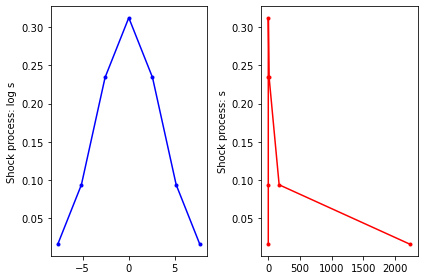

Sum P given col over rows =  [0.94 1.02 1.03 1.03 1.03 1.02 0.94]
Sum P given row over cols =  [1. 1. 1. 1. 1. 1. 1.]


array([[4.45418813e-04, 5.83237856e-03, 7.63700108e-02, 1.00000000e+00,
        1.30941451e+01, 1.71456635e+02, 2.24507805e+03]])

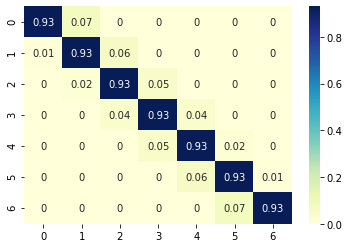

In [10]:
# Let's explore what's in the discretized markov chain from Quant Econ
mc  = qe.markov.approximation.rouwenhorst(ns, 0, σ, ρ)

# mc is a dictionary: look at print(mc.__dict__)

# Get a stationary distribution from the qe.markov.core.MarkovChain class defined over P 
s_grid = exp(np.asarray(mc._state_values)) # spits out tuple, we want array; we don't want it in logs
s_grid.shape = (ns,1) # turn into an proper vector

s_dist = mc.stationary_distributions.T # Transposing is easy! 

Π   = mc.P # Markov transition matrix  -> Can work with greek leter!
Π_T = Π.T # store transpose
              
print('Dispersion parameter: σ = ' , σ)
plt.subplot(1, 2, 1)
plt.plot(log(s_grid),s_dist,'b.-')
plt.ylabel('Shock process: log s') 
plt.subplot(1, 2, 2)
plt.plot(s_grid,s_dist,'r.-')
plt.ylabel('Shock process: s')
plt.tight_layout()
plt.show()

sns.heatmap(np.round(Π,2),annot=True,cmap="YlGnBu")

print('Sum P given col over rows = ', np.round(Π.sum(axis=0),2))
print('Sum P given row over cols = ', Π.sum(axis=1))

s_grid.T


This process can be discretized with a $n_s$ point Markov chain with transition matrix $\Pi=[P(i \rightarrow j)]_{(i,j)}$ so that adding over columns allows us to take proper expectations for a fixed origin, or row. Again in math: 

$$ \sum_{j \in S_{m+1}} P[i, j]=1 $$

A word of caution, always plot and display everything to know what you're getting. Both packages give you the same probability matrix, however, they give extremely high or low values for the nodes, which can give you trouble down the road.

Dispersion parameter: σ =  0.7


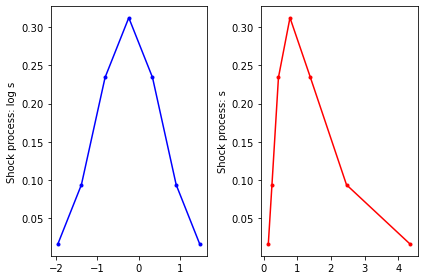

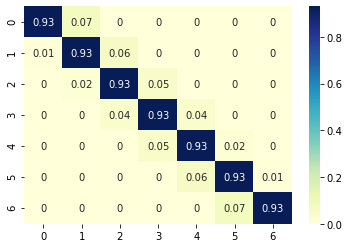

In [15]:
# We can also use a package in utilities instead of quantecon 
s_grid, s_dist, Π = utilities.markov_rouwenhorst(ρ, σ, ns)

# Easier to work with than the QuantEcon package

print('Dispersion parameter: σ = ' , σ)
plt.subplot(1, 2, 1)
plt.plot(log(s_grid),s_dist,'b.-')
plt.ylabel('Shock process: log s') 
plt.subplot(1, 2, 2)
plt.plot(s_grid,s_dist,'r.-')
plt.ylabel('Shock process: s')
plt.tight_layout()
plt.show()

sns.heatmap(np.round(Π,2),annot=True,cmap="YlGnBu")

s_grid.T
param['s_grid'], param['s_dist'], param['Π'], param['Π_T'] = s_grid, s_dist, Π, Π.T

**Discretizing the asset grid**

The other main challenge is to pick a grid for assets. One option would be to pick a uniformly spaced grid (equi-distant in levels). But linear interpolating between grid points leads to error when the actual policy functions are nonlinear, so it is best to have a greater density of grid points where the asset and consumption policy functions are highly nonlinear — which tends to be near the borrowing constraint.

Another advantage of a non-uniform grid that has denser points near the borrowing constraint and sparser points for high assets is that this makes it cheaper to have a high maximum for assets. A high maximum is useful for these models, which tend to have a skewed distribution of assets.

A simple way to concentrate grid points closer to the borrowing constraint is to make $a-\underline{a} + p$ uniformly spaced in log terms between $p$ and $\bar{a} - \underline{a} + p$, for some small $p$, where $\bar{a}$ is the maximum asset level on our grid. The `np.geomspace` function does this spacing. We'll choose $p=0.5$ somewhat arbitrarily.


Two a grids steps


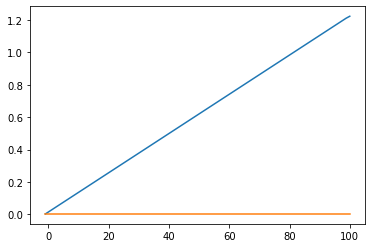

ms_grid.shape =  (7, 500)
[[0.141 0.141 0.141 0.141 0.141 0.141]
 [0.25  0.25  0.25  0.25  0.25  0.25 ]
 [0.443 0.443 0.443 0.443 0.443 0.443]
 [0.785 0.785 0.785 0.785 0.785 0.785]
 [1.391 1.391 1.391 1.391 1.391 1.391]]

ma_grid.shape =  (7, 500)
[[-1.    -0.997 -0.994 -0.991 -0.988 -0.984]
 [-1.    -0.997 -0.994 -0.991 -0.988 -0.984]
 [-1.    -0.997 -0.994 -0.991 -0.988 -0.984]
 [-1.    -0.997 -0.994 -0.991 -0.988 -0.984]
 [-1.    -0.997 -0.994 -0.991 -0.988 -0.984]]

mDispInc.shape =  (7, 500)
[[0.139 0.139 0.139 0.139 0.139 0.139]
 [0.248 0.248 0.248 0.248 0.248 0.248]
 [0.441 0.441 0.441 0.441 0.441 0.441]
 [0.783 0.783 0.783 0.783 0.783 0.783]
 [1.388 1.388 1.388 1.388 1.388 1.388]]


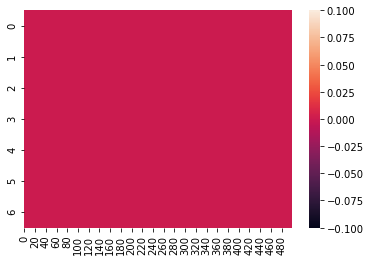

In [25]:
# Two ways to discretize wealth grids 

#a_grid  = linspace(amin,amax, num = na) # equidistant in levels
a_grid  = utilities.agrid(amax,na, amin) # equidistant in logs
# you could code this directly via
# p = 0.5 # arbitrary value
# a_grid = np.geomspace(p, amax - amin + p, nA) + amin - p

step0   = a_grid[1] - a_grid[0]
step = np.ones(na) # build step to next gridpoint array for non-equidistant grid levels
for i in range(0,na-1): step[i] = a_grid[i + 1] - a_grid[i]
step[-1] = 1.01*(a_grid[-1] - a_grid[-2])
step

print('Two a grids steps')
plt.plot(a_grid,step)
plt.plot(a_grid,step[0]*np.ones_like(a_grid))
plt.show() 

# Create a mesh 
ma_grid, ms_grid = np.meshgrid(a_grid,s_grid) 

print('ms_grid.shape = ', ms_grid.shape)
print(np.round(ms_grid[0:5,0:6],3))  # ms_grid fixes the value of a (row) and shocks s (col)
print("")
print('ma_grid.shape = ',ma_grid.shape)
print(np.round(ma_grid[0:5,0:6],3)) # ma_grid fixes the value of s (col) and changes a (row)

# We will be working with "Disposable income" extensively
mDispInc = (1+r) * ma_grid + ms_grid*Y

print("")
print('mDispInc.shape = ', mDispInc.shape)
mDispInc.shape
print(np.round(mDispInc[0:5,0:6] - ma_grid[0:5,0:6] ,3))

sns.heatmap(mDispInc - ma_grid <= 0)

# Note that if disposable income < 0 may not matter if the agent could borrow infinitely much. 

# Create an initial guess for the distribution repmatting the Markov distribution : x na
s_dist.shape # ns,1
D = np.kron(np.ones((na,1)),s_dist).T
D = D / np.sum(np.sum(D)) # Make proper density 
Dguess = D

param['a_grid'], param['ma_grid'], param['ms_grid'], param['mDispInc'], param['Dguess'] , param['step'] = a_grid, ma_grid, ms_grid, mDispInc, Dguess, step

Try running the above code using the high-variance income process that comes from QuantEcon's `mc` instead of `utilities` with very low lows and high highs, and use a logpoint grid. You'll see part of the disposable income turns negative, even after accounting for the extra influx from cash borrowing. You want to be careful about having negative values somewhere in the state space since this implies negative consumption, which CRRA preferences can't handle. 

**Disposable Income and the Natural Borrowing Limit**

Note we can automatically know the agent's disposable income in a period as a function of ideosyncratic and aggregate states only. This disposable income will be allocated by the households between consumption and savings.

$$ c_{t} + a_{t} = DI_t =\left(1+r_{t-1}\right) a_{t-1}+s_{t} Y_{t} $$

In the steady state (or for any given sequence of aggregates you can guess) we can always compute per-period disposable income (or cash-on-hand) for each household, and thus, implied consumption at the constraint 

$$ \underline{c}_{t} = DI_t - \underline{a}$$

We better make sure that the minimum value we feed in here is positive! Otherwise $\log (\underline{c}) \rightarrow -\infty $. We can write an easy assert noting that

$$ \underline{c} = r a_{\min}+s_{\min} Y > 0 \iff  a_{\min} = - \frac{s_{\min} Y}{r} $$

Thus, for whatever income process we chose, we better make sure that we are not violating this **natural borrowing limit** when setting our ad-hoc constraint. After all, no bank would optimally want to lend to a person who could not repay them if they were always unemployed! (Note the RHS of the above equation is the annuity value of the worst state). 

You can read about this in page 666 of the original Aiyagari QJE paper [http://drphilipshaw.com/AyagariQJE94.pdf] 

$$ \begin{array}{c}
a_{t} \geq a_{min} = -\phi \\
\phi \equiv \min \left\{b, w l_{\min } / r\right\}, \text { for } r>0 ; \quad \phi \equiv b, \text { for } r \leq 0
\end{array}$$

In [17]:
# Make sure natural borrowing limit not violated under our calibration
print('Ad hoc borrowing limit = ', amin)
print('Natural borrowing limit = ', - s_grid[0]*Y/r)
amin = - min(-amin,s_grid[0]*Y/r)
print('Model borrowing limit = ', amin)
param['amin'] = amin

Ad hoc borrowing limit =  -1
Natural borrowing limit =  -56.54775947189092
Model borrowing limit =  -1


Takeaways

1. Always check whether the parameters of the model you input do not violate economics
2. Try working with log-spaced grids or ones that are denser where the action is
3. Try always plotting what you get from different canned packages to make sure it looks right
4. Always store parameters neatly into a dictionary to pass to functions, update output

After defining the above dictionary `param` simply type


In [18]:
param

{'amin': -1,
 'amax': 100,
 'na': 500,
 'u': <function __main__.<lambda>(c)>,
 'up': <function __main__.<lambda>(c)>,
 'up_inv': <function __main__.<lambda>(c)>,
 'ρ': 0.975,
 'σ': 0.7,
 'β': 0.98,
 'Y': 1,
 'r': 0.0025,
 'backward_tol': 1e-08,
 'backward_maxit': 5000,
 'forward_tol': 1e-10,
 'forward_maxit': 100000,
 'shooting_tol': 0.001,
 'shooting_maxit': 5000,
 's_grid': array([0.1413694 , 0.25036602, 0.44339966, 0.78526334, 1.3907059 ,
        2.46294815, 4.36189533]),
 's_dist': array([0.015625, 0.09375 , 0.234375, 0.3125  , 0.234375, 0.09375 ,
        0.015625]),
 'Π': array([[9.27305052e-01, 7.04282318e-02, 2.22874151e-03, 3.76158905e-05,
         3.57112885e-07, 1.80816650e-09, 3.81469727e-12],
        [1.17380386e-02, 9.28047966e-01, 5.87090011e-02, 1.48606575e-03,
         1.88094521e-05, 1.19041443e-07, 3.01361084e-10],
        [1.48582767e-04, 2.34836004e-02, 9.28493857e-01, 4.69747253e-02,
         8.91687069e-04, 7.52378082e-06, 2.38075256e-08],
        [1.88079453e-06,

## 2 Backward Iteration to Solve the Bellman:  Carroll's Endogenous Gridpoint Method

Here, we will apply backward iteration to a technique based on Policy/Value Function Iteration that adapts the Carrol's Endogenous Grid-Point Method. Ludwig has created some beautiful and detailed (3-page) document (`endogenous gridpoints method.pdf` note) for you on the EGM method. Please look at them if you have the time (see Canvas \Section Notes folder). *I've added some comments to his summary outline to help you parse through it if you don't want to go through the PDF*

**Motivation** Unlike VFI methods you might be used from 1st year, we will iterate not on $V$ directly, but rather on $V_{a}$. This is a method particular to household consumption-savings models (in firm models it might be more efficient to iterate on ex-ante value functions $EV$ or to parameterize $V$ on Chebyshev polynomials and iterate on the polynomial's coefficients), where it's really fast, and builds on the fact that we can exploit the 3 key equations to solve the policy recursively for *unconstrained* households

$$ u^{\prime}\left(c_{t}\right) \leq \beta \mathbb{E}_{t}\left[\frac{\partial V_{t+1}}{\partial a_{t}}\left(s_{t+1}, a_{t}\right) \mid s_{t}\right] ,  \quad \frac{\partial V_{t+1}}{\partial a_{t}}\left(s_{t+1}, a_{t}\right)=u^{\prime}\left(c_{t+1}\right)\left(1+r_{t}\right) ,\quad c_{t} + a_{t} =\left(1+r_{t-1}\right) a_{t-1}+s_{t} Y_{t}$$

**Outline of Algorithm** 

You will write a backward function that operationalizes a recursive step of the household problem

$$ V_{a}(s_t,a_{t-1};\{\mathbf{r},\mathbf{Y}\}) \leftarrow  F_{\mathcal{B}}\left(V_{a}(s_{t+1},a_t;\{\mathbf{r_{+1}},\mathbf{Y_{+1}}\}\right) $$

In each iteration, we start with $V_{a,t+1}(s',a')$ at all grid points $(s',a')\in\mathbf{S}\times\mathbf{A}$, and aim to calculate the time-t policy functions $a_{t}'(s,a)$ and $c_{t}(s,a)$, along with $V_{a,t}(s,a)$, at all grid points $(s,a)\in\mathbf{S}\times\mathbf{A}$. That is, we take as given (as an input) the marginal value function tomorrow, a $(n^s,n^a)$ array

$$ V^{0}_{a,{t+1}}= \frac{\partial V^{0}_{t+1}}{\partial a_{t}}\left(s_{t+1}, a_{t}\right) $$ 

#### Step 1: discounting and expectations. 

Calculate $W_{a,t}(s,a')\equiv\beta\mathbb{E}[V_{a,t+1}(s',a')|s]$ for all grid points $(s,a')\in\mathbf{S}\times\mathbf{A}$.

To do this, given an $|\mathbf{S}|\times|\mathbf{A}|$ matrix $\mathbf{Va}$ containing all $V_{a,t+1}(s',a')$, calculate $\mathbf{Wa}=\beta\Pi\mathbf{Va}$ where $\Pi=[\pi_{s,s'}]$ is the Markov transition matrix. The resulting matrix $\mathbf{Wa}$ contains all $W_{a,t}(s,a')$.

#### Step 2: solving for the asset policy using the first-order condition.

2.1 Calculate $c_{t}^{endog}(s,a')\equiv(u')^{-1}(W_{a,t}(s,a'))$. Note this applies the **first order condition** to derive $c_{t}^{\text {next }}=c_{t}^\text {next}\left(s_{t}, a_{t}\right)$, another  $(n^s,n^a)$ array. This requires taking the expectation over the exogenous state $s_{t+1}|s_{t}$, which can be easily done with our Markov matrix. You can do step 1 and 2 in one go:

$$ c_{t}^{\text {next}} = c_{t}^\text {next}\left(s_{t}, a_{t}\right) = (u^{\prime})^{-1}\left( \beta \mathbb{E}_{t}\left[V^{0}_{a,{t+1}} \right]\right) = (u^{\prime})^{-1}\left( \beta \: \Pi_{ss'} \: V^{0}_{a,{t+1}} \right) $$

2.2 Use the **budget constraint**, where the RHS -- cash on hand ($coh$) or disposable income ($DI$), which we will use interchangeably -- stored in memory as a function of $a_{-}$ and does NOT change with our guesses, while the LHS is a function of future assets $a$ directly and via $c_{t}^\text {next}\left(s_{t}, a_{t}\right)$: different guesses for the marginal value will yield different allocations of disposable income between consumption and savings. Construct each of the two sides for a given $s_t$

$$ c_{t}^\text {next}\left(s_{t}, a_{t}\right) +a_{t} = \operatorname{LHS}_t\left(a_{t}\right) = \operatorname{RHS}_t\left(a_{t - 1}\right)= DI_t = \left(1+r_{t-1}\right) a_{t-1}+s_{t} Y_{t} $$ 

2.3 Then, for each $s\in\mathbf{S}$, linearly interpolate each point $coh_{t}(s,a)$ (for all $a\in\mathbf{A}$) against the data points $\{(c_{t}^{endog}(s,a')+a',a')\}_{a'\in\mathbf{A}}$ to obtain the policy $a'_{t}(s,a)$. This finds $c_{t}\left(s_{t}, a_{t-1}\right)$ as a function of current assets $a_{-}$. This means, use linear *interpolation* to find the approximate grid point $a_{t}$ next period corresponding to any given $a_{t-1}$ today given $s_{t}$. That is, find the $a_{t}\left(s_{t}, a_{t-1}\right)$ that is to the $\operatorname{RHS}\left(a_{t - 1}\right)$ in the same proportion of what $a_{t}$ is to the $\operatorname{LHS}\left(a_{t}\right) = c_{t}^\text {next}\left(a_{t}\right) +a_{t}$. `utilities.py` has some standard routines for interpolation, optimized for efficiency via Numba (vectorized). `yq = utilities.interpolate_y(x, xq, y)` gives us the `yq` that is to `xq` what `y` is to `x` on different grids. It's advantage is that it uses vectors. Alternatively, you can use the native NumPy `np.interp` which has the same structure, but only works in 1D arrays, so you'd have to use loops. Interpolation is a very useful technique used to iterate on value functions and distributions, and one can use linear, polynomial, spline-based interpolation for different problems. [https://en.wikipedia.org/wiki/Interpolation] ![Interpolation Examples](../figures/INTERPOLATION.png) 

#### Step 3: enforcing the borrowing constraint and backing out consumption.
Enforce the borrowing constraint $a'_{t}(s,a)\geq\underline{a}$ by replacing $a'_{t}(s,a)$ with $\max(a'_{t}(s,a),\underline{a})$. Then compute $c_{t}(s,a)=coh_{t}(s,a)-a_{t}'(s,a)$.

3.1 For some values of $a_{t-1}$ (and given low $s_t$) the associated/interpolated $a_{t}\left(s_{t}, a_{t-1}\right)$ is likely to  lie below $\underline{a}$ - if unconstrained consumption implied by our guess of $V_a$ is unrealistically high. Thus, for those agents to satisfy the **borrowing constraint** we need $a_{t}\left(s_{t}, a_{t-1}\right)=\underline{a}$

3.2 Given the implied savings policy $a_{t}=\mathbf{a}_{t}^{*}\left(s_{t}, a_{t-1}\right)=\max\left[a_{t}\left(s_{t}, a_{t-1}\right),\underline{a}\right]$ solve for consumption on the current grid exploiting the budget constraint (Note: by making sure that the natural borrowing limit was never violated, we have made sure that such consumption level will always be positive, and hence, the marginal value function will be bounded). 

$$ \mathbf{c}_{t}^{*}\left(s_{t}, a_{t-1}\right) = \operatorname{RHS}_t\left(s_{t},a_{t - 1}\right)  - \mathbf{a}_{t}^{*}\left(s_{t}, a_{t-1}\right)$$ 

#### Step 4: using the envelope condition to recover the derivative of the value function.
Compute $V_{a,t}(s,a)=(1+r_{t})u'\left(c_{t}(s,a)\right)$.

To recap, we assumed a guess for the (future) marginal value function, and used that to derive an implied consumption policy. We can use this to compute a new guess for the marginal value function using the **envelope condition**

$$ V^{1}_{a,{t-1}}\left(s_t,a_{t-1}\right)=u^{\prime}\left(\mathbf{c}_{t}^{*}\left(s_{t}, a_{t-1}\right)\right)\left(1+r_{t-1}\right)$$

*Starting guess* Note that this algorithm requires a starting guess for the last marginal. A possibility could be the one corresponding to being at the terminal steady state and consuming a fixed proportion of disposable income $m\in (0,1)$.

$$ V^{0}_{a}\left(s,a_{-}\right)=u^{\prime}\left(m \operatorname{DI}\left(s,a_{-}\right)\right)\left(1+r\right),\quad DI(s,a_{-}) = \left(1+r\right) a_{-}+s Y$$


**Implementation of backward iteration**

Here's an example of how a simple backward iteration function should look like for "household" taking as given $V_{a,t+1}$, parameters, and aggregate states at t, returning today's optimal policies as well as our new $V_{a,t}$. Much of this is self-explanatory given the steps above. Note the Python operators `@` for matrix multiplication and `**` for exponentiation. 

In [174]:
# Pseudo-code to help you as a template:

# def household(Va guess,parameters,aggregates):
#     β ...  = param['β'] ... # unpack param if needed
#     
#     c_next = ... # Apply FOC to get c on t+1 grid from Va guess

#     DI     = ... # Disp Income from budget constraint: (1+r)a_ + sY

#     # Interpolate a onto RHS = DI in a_ metric, what a is to LHS given c_next in a metric
#     a      = ...  # Recall: yq = utilities.interpolate_y(x, xq, y) or use NumPy's native `np.interp` in loop

#     utilities.setmin(...) # Make sure a satisfies the constraint! can also use NumPy's native maximium

#     c      = ... # Implied c on the current grid

#     Va     = ... # Envelope condition updates our guess of Va @ t

#     return Va, a, c

# Solving for the steady-state policies

Given this backward iteration on $V_{at}$, it's standard to solve for a steady state — the only difference from the case we might be used to is that we're iterating on the derivative of the value function rather than the level of the value function. Assuming we are at a **candidate Steady State** where we fix $Y,r$, applying our map iteratively until convergence 

$$ V_{a}(s_t,a_{t-1};r,Y) \leftarrow  F_{\mathcal{B}}\left(V_{a}(s_{t+1},a_t;r,Y\right) $$

allows us to solve for the consumption and savings policies as a function of existing holdings for different income shock realizations.


We need:
- An initial guess for steady-state $V_a$
- Then to iterate backward until we hit some termination criterion (you can check convergence in policies $a$, although a much faster route in my experience is checking convergence in $V_a$ directly. 

Many different choices will deliver good performance. For now, we can just make some ad-hoc choices:
- make a guess that consumption $c$ equals some percentage (5%) of cash-on-hand/disposable income, then turn this into a guess for $V_a$ using the envelope condition (step 4 above)
- terminate backward iteration once the max distance between the asset policy function on two successive iterations falls below some tolerance, say $10^{-9}$
    * (we can also have a maximum number of iterations, say 10,000, as a fail-safe so that the computer doesn't run forever if it isn't converging)



Here's pseudo-code to help you write a function to do so:

In [19]:
# Pseudo-code to help you as a template:

# def function Va, a, c = backward_ss(param,r,Y)
#     # unpack param if needed

#     Va0 =  ... # guess Va0 matrix using Euler
#     # iterate on your map

#     for t in range(0,param['backward_maxit']):
#         Va_p       = Va0 # update Va(t+1). also update a_old  = a if you iterate on the policy    
#         Va0  ...   =  household(Va_p,...) # Update Va(t)
#         if ... # check convergence: hint choose a metric (np.linalg.norm(Va_p-Va0)),(np.max(np.abs(a - a_old)) 
#             break # if your choice of object converged        
# return equilibrium objects in the steady state

## Obtaining and inspecting steady state

We will first solve for the steady state policies by iterating backwards given fixed aggregates. We won't look at the solutions in depth, but let's plot the consumption policy functions and net savings. 

In [ ]:
%%time

Va, a, c    = backward_ss(param,r,Y)      # iterate until Va converges (faster!)
#Va, a, c    = backward_ss_pol(param,r,Y) # iterate until a converges (slower!)

In this model, we have net investment/savings (like capital investment on the firm side, but without depreciation)

$$ \Delta_a^{*}\left(s, a_{-}\right) = a^{*}\left(s, a_{-}\right)-a_{-}  $$

When this is positive, the agent is savings. Otherwise, the agent is depleting asset holdings.

When an agent gets a bad income realization, they will tend to draw down their credit line, depleting their savings to smooth the shock. They'll only be able to do this up to the point when they get close to the constraint.  

When an agent gets a good income realization, they will tend to build up a "buffer stock" of savings to save for a rainy day in precaution. The model predicts that all agents below certain wealth threshold will save most of the good income shock, while those with high assets (away from the constraint) will tend to deplete. 

For each income, households target a given “buffer-stock” level of assets. For lower incomes, this is the borrowing constraint itself. 

When agents are closer to the constraint, they have even shorter time horizon in mind, do not plan for the future, are hand-to-mouth, and thus, have higher MPC ($\partial c(s,a_{-})/\partial a_{-}$). This is in sharp constrains with the Rep agent's $M P C^{R A}=r$. Only very high income folks with high assets have MPCs as low as these. Although the presence of the constraint affects everyone elsewhere in the distribution (via the value function, since everyone has the possibility of becoming constrained at some point if they get a bad enough sequence of bad shocks). MPCs are much higher here because households have shorter horizons: household's don't smooth forever, and have even shorter horizons close to the constraint. 

Finally, if we look at the entire function, it seems almost linear, especially for those with a good income shock and because at such high levels of assets it is approximately linear, with households behaving as if they are permanent income.

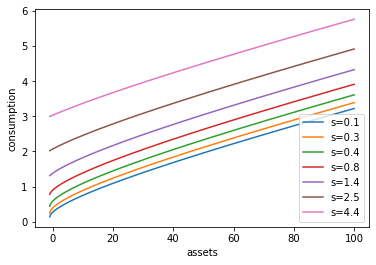

Non-linearity = Consumption policy functions: smin, σ =  0.7


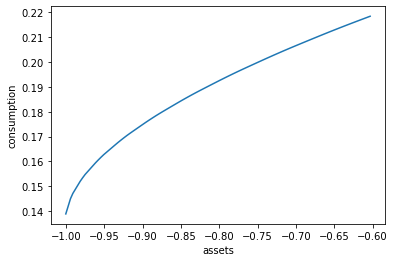

Linearity = Consumption policy functions: smax, σ =  0.7


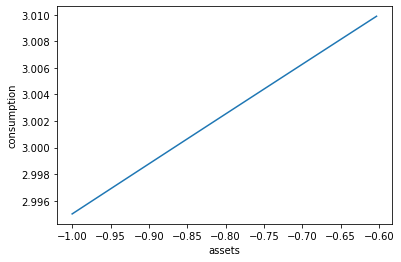

Heading to constraint = Net savings a - a_: smin, σ =  0.7


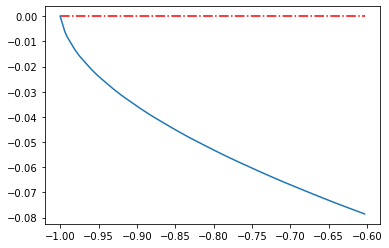

Buffer stock = Net savings a - a_: smax, σ =  0.7


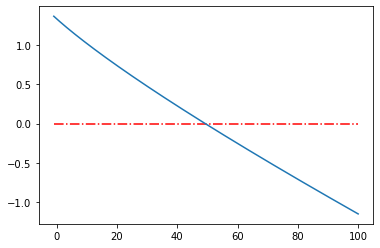

In [212]:
for s, ys in enumerate(s_grid):
    plt.plot(a_grid, c[s, :], label=f's={round(ys,1)}')
plt.legend()
plt.xlabel('assets')
plt.ylabel('consumption');
plt.show()

aplt = 80

print('Non-linearity = Consumption policy functions: smin, σ = ' , σ)
plt.plot(a_grid[0:aplt],c[0,0:aplt])
plt.xlabel('assets')
plt.ylabel('consumption');
plt.show()

print('Linearity = Consumption policy functions: smax, σ = ' , σ)
plt.plot(a_grid[0:aplt],c[-1,0:aplt])
plt.xlabel('assets')
plt.ylabel('consumption');
plt.show()


It is also interesting to plot net saving - the increase or decrease in assets. At higher incomes, people are net savers until they reach a high level of assets.

Heading to constraint = Net savings a - a_: smin, σ =  0.7


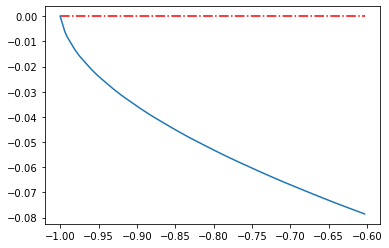

Buffer stock = Net savings a - a_: smax, σ =  0.7


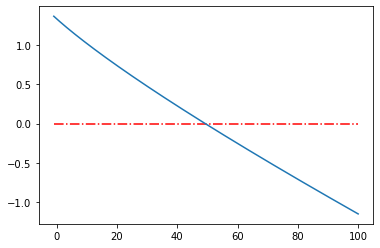

In [214]:

print('Heading to constraint = Net savings a - a_: smin, σ = ' , σ)
plt.plot(a_grid[0:aplt],np.zeros(aplt),'r-.')
plt.plot(a_grid[0:aplt],a[0,0:aplt] - a_grid[0:aplt])
plt.show()

print('Buffer stock = Net savings a - a_: smax, σ = ' , σ)
plt.plot(a_grid,np.zeros_like(a_grid),'r-.')
plt.plot(a_grid,a[-1,:] - a_grid)
plt.show()



Note the above graph confirms that people getting better shocks eventually are able to get out of their debt zone, having net asset "targets" away from the constraint (building a "buffer stock" for a rainy day). Further, their consumption functions are smooth, in the sense that they don't have the non-linearity we saw for people at the bottom.

## 3 Forward Iteration of the Distribution & Young's Histogram/Lottery Discretization Method

## Reviewing Het Agent Distribution Matrices

In the steady state, solving for the distribution is easy. Let $D(s, \mathcal{A})$ be the measure of agents with wealth $a \in \mathcal{A}$ and income state $s$, then 

$$ D\left(s^{\prime}, \mathcal{A}\right)=\sum_{s} \pi_{s^{\prime} s} D\left(s, a^{*}(s, \cdot)^{-1}(\mathcal{A})\right) $$


where $\pi_{s^{\prime} s}$ belongs to the Markov transition matrix of $s$, with stationary distribution $p_s$. Since after discretizing $a$, it is no longer continuous, we apply Young's histogram method to solve for the stationary distribution. In the Appendix, I have outlined other methods to deal with the distribution in a more semi-parametric way (i.e. approximating with a polynomial over the grid and solving for it's coefficients).

We can then compute aggregates

$$ A=\sum_{s} p_{s} \int a_{-} D\left(s, d a_{-}\right) \quad C=\sum_{s} p_{s} \int c^{*}\left(s, a_{-}\right) D\left(s, d a_{-}\right) $$

Let's discretize the distribution $D$ not just over $s$ but also over $a_{-}$

Since we are discretizing a, we can write

$$ D\left(s^{\prime}, a\right)  = \sum_{s} \pi_{s^{\prime} s} \sum_{a_{-}} pr\left[a(s, a_{-}) \in N_1(a)\right] D(s, a_{-})  $$

Note that $ pr\left[a_1(s, a_{-}) \in N(a)\right] $ is the probability that, in $t = 1$ given $(s, a_{-})$ an agent chooses optimal savings policy that is in the neighborhood of of the future asset grid point $a$, to be inherited in $t = 2$. 

How do we go about this? The original Krusell-Smith uses Monte Carlo (stochastic) simulation to generate an updated cross-sectional distribution. This method is very time consuming.  Here's another non-parametric way to do this (in the appendix, I have outlined a semi-parametric method by Thomas Winberry if you're interested).

## Young's Histogram Method  as a Markov Investment Success Shock 

*Simple example with 2-exogenous states* 

A fine histogram approximates the distribution of households along a discrete set of points, which is considerably faster than the Monte Carlo approach. It was developed in a paper Young (2010), which is highly cited all over the het agent macro literature. 

http://people.virginia.edu/~ey2d/young_2010.pdf

I will follow Young's notation, in which, as in Krusell Smith, there's only two exogenous states $\varepsilon = e$ employment and $ \varepsilon= u$ unemployment. He wants to approximate the distribution's transition, with the mass of the distribution being $\Gamma_{t}(k, \varepsilon)$. 

1. Locate the policy function $k_{t+1} = k^{\prime}\left(k, \varepsilon\right)$ in the grid finding the index $J$ such that $k^{\prime}\left(k, \varepsilon,\right) \in\left[k_{J}, k_{J+1}\right]$ lies in between two grid points $J$ and $J+1$

2. Define the weights corresponding to the distance between our policy and each of the two grid-points. We will be conducting a reassignment of individuals to the end points of the interval, where the measure is determined by **how close the true decision rule lies to each endpoint**. Note if $k^{\prime}\left(k, \varepsilon\right) \approx k_{J} $ is close to the bottom then $\omega \approx 1$, while if $k^{\prime}\left(k, \varepsilon\right) \approx k_{J+1} $ is close to the top then $\omega \approx 0$.

$$  \text{ LEFT } \quad \omega=1-\frac{k^{\prime}\left(k, \varepsilon\right)-k_{J}}{k_{J+1}-k_{J}} , \quad \text{ RIGHT } \quad 1- \omega = \frac{k^{\prime}\left(k, \varepsilon\right)-k_{J}}{k_{J+1}-k_{J}} $$

2a. To have a good way to remember this, note that another way to think about this is understanding that a policy falling in between two grid points can be expressed as a linear combination of the two. In our Huggett model notation $ \mathbf{a}_{t}^{*}\left(s_{t}, a_{t-1}\right)=\lambda a_{t}^{0}+(1-\lambda) a_{t}^{1}$

3. Note that for any two points $\varepsilon:(e,u) \rightarrow (e,u)$ with probabilities $\pi_{e \mid \varepsilon},\pi_{u \mid \varepsilon} = \pi_{e \mid e},\pi_{u \mid e},\pi_{e \mid u},\pi_{u \mid u}$. Allocate current mass $\Gamma_{t}(k, \varepsilon)$ to points in the grid according to weights:

$$ \text{ LEFT } \quad \left(k_{J}, e\right), \quad \left(k_{J}, u\right), \quad  \text{ RIGHT } \quad \left(k_{J+1}, e\right),\quad  \text { and } \quad \left(k_{J+1}, u\right)$$

$$  \text{ LEFT }  \quad \omega \cdot \pi_{e \mid \varepsilon}, \quad \omega \cdot \pi_{u \mid \varepsilon}, \quad  \text{ RIGHT } \quad(1-\omega) \cdot \pi_{e \mid \varepsilon},  \quad \text { and } \quad (1-\omega) \cdot  \pi_{ u \mid \varepsilon} $$

We will think of this below as being the expected outcome of a random lottery an agent saving plays.

*Graphical interpretation of 2 state example* 

1. consider the case of two agents staring out with the same capital stock $k$ at $t$ (on the capital grid), but with two different states on the shock grid. Naturally, the employed one will have had more income, and be able to save more for next period: $g(k,\varepsilon = e) > g(k,\varepsilon = u)$

2. regardless of whether the agent that was employed when making the investment decision then goes on to get $\varepsilon' = e,u$ as the next period shock realization, they will be stuck with the same pre-determined choice of $g(k,\varepsilon = e)$.  However, this policy may lie in between two grid points, the original $k$ and another $k_{+1}$ since agents with good shocks will tend to want to save. 

3. Thus, we force that a share $\omega$ of such agents with $g(k,\varepsilon = e)$ stay with the same capital stock $k$ on the grid, while a share $1-\omega$ of agents are able to move a higher planned capital gridpoint next period $k_{+1}$. Out of each of those two groups, the productivity Markov process will take a share $\pi_{e \mid e}$ to employment again, while a share $\pi_{u \mid e}$ will eventually become unemployed.

![Young 2010](../figures/Young_2010.png) 

*Back to our Huggett Notation with multiple any exogenous state grid points*

Given this discretization,  and given that almost surely savings policies will lie in between grid points, the **intermediate distribution** before aggregating over shocks agents receive coming out of $t = 1$, but after they've made their forward looking investment choice.

$$ \tilde{D}_{1}\left(s, a_p\right)  =  \sum_{j| a_{p-1} < a_1(s, a_j) < a_{p+1}} pr\left[a_1(s, a_j) \in N_1(a_p)\right] D_0(s, a_{j})  $$

Where as above

$$  \text{ LEFT } \quad \omega=1-\frac{k^{\prime}\left(k, \varepsilon\right)-k_{J}}{k_{J+1}-k_{J}} , \quad \text{ RIGHT } \quad 1- \omega = \frac{k^{\prime}\left(k, \varepsilon\right)-k_{J}}{k_{J+1}-k_{J}} $$

Armed with that, we can build the post-shock incoming distribution agents will start with in the following period.


$$ D_{1}\left(s^{\prime}, a_p\right)  = \sum_{s} \pi_{s^{\prime} s}  \tilde{D}_{1}\left(s, a_p\right)  $$

Equivalently, remembering the fact we reviewed about Markov transition matrices, a given column of the distribution 

$$ D_{1}\left(:, a_p\right)  = \Pi^{\prime}  \tilde{D}_{1}\left(:, a_p\right)  $$

$$ D_{1}  = \Pi^{\prime}  \tilde{D}_{1}  $$

Giving us the last step in the transition matrix. 

Now for the endogenous (policy-dependent) transition, we need to apply a map such that 

$$  \tilde{D}_{1}  = T^{\prime}  D_{0}  \implies D_{1}  = \Pi^{\prime}  \left(T^{\prime}  D_{0}  \right)  $$ 

However, inspecting the sum above over $j| a_{p-1} < a_1(s, a_j) < a_{p+1}$ we can already suspect that such $T$ will be super sparse. 

## Step by Step

1. Take as given $D_{t-1}\left(s_{t}, a_{t-1}\right)$ over $n^{s} \times n^{a}$. Our goal is to find $D_{t}\left(s_{t+1}, a_{t}\right)$.
2. First construct $\tilde{D}_{t-1}\left(s_{t}, a_{t}\right)$ by looping over each current asset grid point $a_{t-1}$

-  The asset policy for this grid point must lie between two next-period grid points 
$$ \mathbf{a}_{t}^{*}\left(s_{t}, a_{t-1}\right)=\lambda a_{t}^{0}+(1-\lambda) a_{t}^{1}$$ 
- For each current gridpoint $s_t,a_{t-1}$, for each future point in the future grid, we can find
$$ 1- \lambda  = \frac{\mathbf{a}_{t}^{*}\left(s_{t}, a_{t-1}\right) - a_{t}^{0}}{a_{t}^{1} - a_{t}^{0}}$$ 

-  Assign $\lambda D_{t-1}\left(s_{t}, a_{t-1}\right)$ mass to $\tilde{D}_{t-1}\left(s_{t}, a_{t}^{0}\right)$ 
-  Assign $(1-\lambda) D_{t-1}\left(s_{t}, a_{t-1}\right)$ to $\tilde{D}_{t-1}\left(s_{t}, a_{t}^{1}\right)$
 

3. Construct $D_{t}\left(s_{t+1}, a_{t}\right)$ by applying the $ P^{\prime}$ transition matrix for shocks


## Lotteries intuition

Suppose that we want to represent the joint distribution of households across states and assets. There are many possible ways we could represent this distribution, but a simple one would be to discretize it using the same grid as for the backward iteration, keeping track of the mass at each grid point.

But this runs into the problem above: household starting at a gridpoint this period will generally not go to an exact grid point next period. How do we keep track of them? 

One solution is to assume that the household follows a "lottery", going to each of the nearest two grid points with some probability, such that on average, the household chooses the right asset value. *We can think of this as using a local first-order approximation.*

In particular, let the grid be $\mathbf{A}=(a_0,\ldots,a_{n_a-1})$. If some policy $a'$ lies in between grid points $a_i$ and $a_{i+1}$, then we want a lottery where the household goes to $a_i$ with probability $\pi$ and $a_{i+1}$ with probability $1-\pi$, such that

$$
\pi a_i + (1-\pi) a_{i+1} = a'
$$

This can easily be solved to give

$$
\pi = \frac{(a_{i+1} - a')}{(a_{i+1} - a_i)} \tag{1}
$$

We now write code that takes in an array `a` giving $a'(s,a)$ for all grid points $(s,a)\in \mathbf{S}\times\mathbf{A}$, along with the array `a_grid` of grid points $\mathbf{A}$. It produces the $i(s,a)$ and $\pi(s,a)$ for the lottery corresponding to $a'(s,a)$, which we store in arrays `a_i` and `a_pi`.

This involves two steps, both for each $(s,a)$.

1. Find the $i$ such that $a'$ lies between grid points $a_i$ and $a_{i+1}$.


2. Implement (1) to convert obtain lottery probabilities $\pi$.


Note that in step 1, there is a question of what to do when $a'$ is either to the left of all grid points (below $a_0$) or to the right of all grid points (above $a_{n_a-1}$). In both cases, we'll choose the $i$ *corresponding to the nearest interval between grid points*: $i=0$ for the former, $i=n_a-2$ for the latter. Of course, in this case, the $\pi$ we get from (1) will lie outside the interval $[0,1]$, which is undesirable and hard to interpret as a "lottery" - which is why we generally want to design our grid to avoid this.

You could build your own lottery function, but Ludwig wrote this one for you:


In [26]:
def get_lottery(a, a_grid):
    
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a) - 1
    
    # step 2: implement (1) to obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])
    
    return a_i, a_pi

Alternatively you can use `x_i, x_pi = utilities.interpolate_coord_robust(a_grid, a)` from the `utilities` module I gave you (returning index $i$ of left grid point and probabilities $pi$ of staying put). As with the `get_lottery` code, it first finds where policy values lay on the grid. Since we are not using grid search, policies won't match with grids exactly: we need to interpolate. As with `get_lottery`, we will find the grid-point just under each investment policy, and compute the $\lambda$s ($\pi$s) probabilities from above. Since policies can be non-monotonic (but grid points are not), we can use the command

`x_i, x_pi = utilities.interpolate_coord_robust(a_grid, a)`
`# Interpolate policy a, finding lower bracketing grid point in x (monotonic) of xq points (not mono)
    # x: array (n) monotonic data points x grid, 
    # xq: array (k, nq), query points (in any order) xq policy
    # =>  x_i : array (k, nq), INDEX of lower bracketing gridpoints
    # => x_pi : array (k, nq), PROBABILITY WEIGHTS on lower bracketing gridpoints`

Which gives both the index of the grid point just under the policy, and the weights of the distribution that should be assigned to it (the rest manages to go up one rung).


Since this is a crucial part of our task, let's inspect what it gives us a bit more carefully:

In [142]:
x_i, x_pi = utilities.interpolate_coord_robust(a_grid, a) # find where a lays on a_grid

assert np.sum(np.sum(((x_pi < np.zeros_like(x_pi)) | (x_pi >  np.ones_like(x_pi) )))) == 0
a_interpol = np.take(ma_grid, x_i) # index ma_grid values according to x_i index
print("a grid")
print(np.round(a_grid[0:5],3)) # previous value
print("Policy off grid")
print(np.round(a[0:7,0:5],3)) # previous value
print("Policy on grid")
print(np.round(a_interpol[0:7,0:5],3)) # current savings
print("Prev value")
print(np.round(a_grid[0:5],3)) # previous value
print("Index")
print(x_i[0:7,0:5])
print("Weight")
print(np.round(x_pi[0:7,0:5],3)) # if you start here, you stay here.

a grid
[-1.    -0.997 -0.994 -0.991 -0.988]
Policy off grid
[[-1.    -1.    -1.    -0.999 -0.998]
 [-1.    -1.    -1.    -1.    -0.999]
 [-1.    -1.    -1.    -1.    -0.999]
 [-1.    -1.    -1.    -0.999 -0.997]
 [-0.96  -0.957 -0.954 -0.952 -0.949]
 [-0.666 -0.663 -0.66  -0.657 -0.654]
 [ 0.16   0.163  0.166  0.169  0.172]]
Policy on grid
[[-1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.   ]
 [-0.961 -0.958 -0.958 -0.954 -0.951]
 [-0.67  -0.67  -0.663 -0.663 -0.655]
 [ 0.147  0.147  0.164  0.164  0.164]]
Prev value
[-1.    -0.997 -0.994 -0.991 -0.988]
Index
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [ 12  13  13  14  15]
 [ 70  70  71  71  72]
 [143 143 144 144 144]]
Weight
[[1.    1.    1.    0.786 0.277]
 [1.    1.    1.    1.    0.618]
 [1.    1.    1.    1.    0.743]
 [1.    1.    1.    0.562 0.054]
 [0.597 0.844 0.089 0.331 0.57 ]
 [0

In [300]:
get_lottery(a[6, 0], a_grid)
# A household that starts at the bottom of the grid but gets the best income shock not shoots up all the way to...

(143, 0.204849331694731)

Heatmap of where household savings are taking them
y-axis: s income shock, x-axis original assets


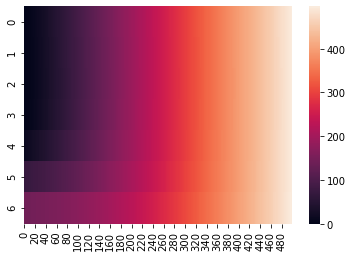

In [305]:
sns.heatmap(x_i)
print('Heatmap of where household savings are taking them')
print('y-axis: s income shock, x-axis original assets')

## Using the lottery to iterate on the distribution

Now, we need to implement the lottery. Suppose that we have a discretized distribution $D(s,a)$ giving the mass at each gridpoint $(s,a)\in \mathbf{S}\times \mathbf{A}$.

At each gridpoint, we want to send a fraction $\pi(s,a)$ of the mass to the asset gridpoint with index $i(s,a)$, and $1-\pi(s,a)$ of the mass to index $i(s,a)+1$.

This is very easy to implement directly, but a straightforward implementation uses `for` loops and be very slow in ordinary Python. Fortunately, a package called Numba allows us to accelerate compatible code by adding a simple `@numba.njit` decorator at the top of the function. This does just-in-time compilation of the code, so that after an initial compilation cost is paid on the first run, the code runs at a speed comparable to compiled languages like C and Fortran.

After households choose their new asset levels $a'$, we have the "end-of-period" distribution $D^{end}(s,a')$. But to get the distribution $D(s',a')$ at the beginning of next period, we also need to update the exogenous state $s$ to $s'$.

Essentially, we want to calculate

$$
D(s',a') = \sum_s \pi_{ss'} D^{end}(s,a')
$$

Given the Markov matrix $\Pi=[\pi_{ss'}]$ and the array $\mathbf{D}^{end}$, this is equivalent to taking the *transpose* of $\Pi$ times $\mathbf{D}^{End}$:

$$
\mathbf{D} = \Pi'\mathbf{D}^{end}
$$

We can now combine this with the forward function above to get a complete forward iteration function, taking us from $D(s,a)$ to $D(s',a')$

**Recall** @ in Python's NumPy can be used to multiply matrices! 

Now you can use these two inputs to write your own forward iteration function

$$ D_{t}(s_{t+1},a_{t};\{\mathbf{r},\mathbf{Y}\}) \leftarrow  F_{\mathcal{F}}\left(D_{t}(s_{t},a_{t-1};\{\mathbf{r},\mathbf{Y}\}\right) $$

You can define a function of the following form

In [217]:
# Pseudo-code for writing a forward step 
# # Try looking at how long forward iteration takes to run without defining it with  @njit
# @njit # vectorizes loops 
# def forward0(D, Π_T, x_i, x_pi): 

#     nZ, nX = ...         # loop over exogenous shocks and endogenous states
#     Dnext  = ...         # pre-fill new matrix 

#     for iz in range(nZ):
#         for ix in range(nX):

#             d   = ...    # element (mass) from the original distribution 
#             i   = ...    # corresponding left gridpoint index of endogenous policy 
#             pi  = ...    # weight on left gridpoint of endogenous policy

#             Dnext[iz, i]    = Dnext[iz, i]   + d*...    # endog policy transitions DOWN 
#             Dnext[iz, i+1]  = Dnext[iz, i+1] + d*...    # endog policy transitions UP
#     return # D1 <- Π'D0: apply exogenous shock transition, get beginning of t+1 dist

In [228]:
# This is a very similar algorithm to stationary_markov(Π,param). Apply transition = forward
# def function D = forward_ss(param,r,Y)
#     D = ... # initialize with some guess (I gave you one already!)
    
#     for t in range(0,forward_maxit):
    
#         Dnext = ...     # Apply forward step
    
#         if t % 10 == 0 and ... check if D after forward iteration is close to your guess
#             return ...  # end if converged, return D
#             break ... 
    
#         D = Dnext    # Update distribution forward for next step

Trying to plot PDFs here might be tricky. We can instead plot the CDF of the distribution to get a better sense of how it looks like. As expected, there's a lot of people at the bottom close to the constraint with a long tail at the top.

CDF(a) of stationary distribution D with dimensions:  (7, 500)


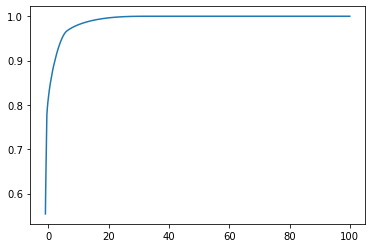

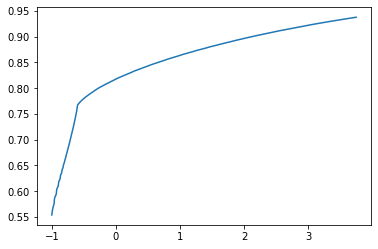

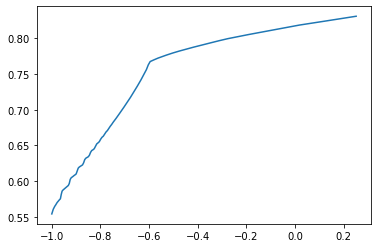

In [248]:
D = forward_ss(param,r,Y)
print('CDF(a) of stationary distribution D with dimensions: ', D.shape )
plt.plot(a_grid, D.sum(axis=0).cumsum())
plt.show()
plt.plot(a_grid[0:250], D.sum(axis=0)[0:250].cumsum());
plt.show()
plt.plot(a_grid[0:150], D.sum(axis=0)[0:150].cumsum());
plt.show()

This has some odd features, which arise from the fact that we discrete states. We can see more by plotting the CDF for each state separately.

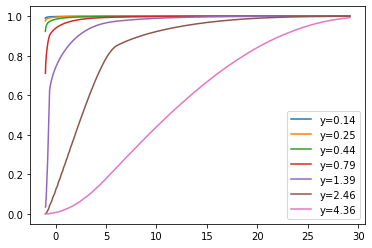

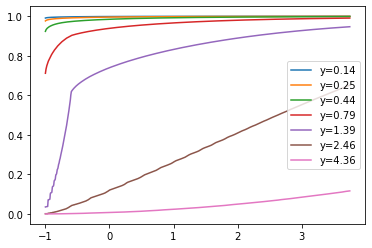

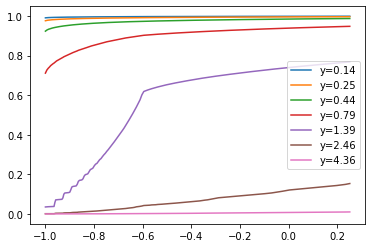

In [258]:
for s, y in enumerate(s_grid):
    plt.plot(a_grid[:400], D[s][:400].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

for s, y in enumerate(s_grid):
    plt.plot(a_grid[:250], D[s][:250].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

for s, y in enumerate(s_grid):
    plt.plot(a_grid[:150], D[s][:150].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

We see that the CDF for the lowest income states start well above 0, because households at these low income often de-cumulate their assets down to the borrowing constraint. The CDF for the medium income states seems to have an upward jumps right in the middle (rising fast below, and slowing down after). This corresponds to the asset target that households with these income try to hit, and where many of them will cluster (much like the borrowing constraint for the poor). 

Finally, the CDF for the higher income states tend to be fairly smooth except towards the bottom in some cases where you can see households who happened to move from low income levels and the borrowing constraint to a higher income level, and make big upward saving strides. At some point, the high-income CDFs hits 1; this corresponds to the much higher asset target that those high-income households try to hit. It's clear how these models can produce a right-skewed distribution of wealth.

To get at measures of average (= aggregate  since we have mass 1 households), all we have to do is sum 

$$ A=\sum_{s} p_{s} \int a_{-} D\left(s, d a_{-}\right) $$

which should be the same (up to numerical error) as the average level of assets chosen for next period, since this is a stationary equilibrium

In [265]:
print('Current aggregate A', round(np.sum(D*a_grid),1))
print('Future aggregate A', round(np.sum(D*a),1))

Current aggregate A 0.0
Future aggregate A 0.0


## Solving for the Steady State

In [268]:
# Create an array of interest rates to plot the asset demand function 

In [ ]:
# Create a function that generates SS aggregates given different r's while holding Y constant  

# def ss(param,r,Y): 
    
#     Π_T ... = param['Π_T'] ...
#     

#     # Step 1: Backward Iteration on SS Policies

#     Va0 = ... # Sensible guess
               
#     for t in range(0,backward_maxit):
#         Va_p       = ...
#         Va0, _ , _ = ... # Apply BACKWARD STEP @ SS candidate
#         if ... # check dist < backward_tol
#             break # end if converged

#     Va, a, c    = ... # get optimal policies given final Va_p

#     # Step 2: Forward Iteration to get SS Distribution given SS Policies
               
#     x_i, x_pi = ... # interpolate policies on grid, find where @
#     D =  ... # guess

#     for t in range(0,forward_maxit):
#         Dnext = ..  # Apply FORWARD STEP @ SS candidate
#         if  ... # check dist < forward_tol
#             break # end if converged

#         D = ...   # Update distribution forward for next step
               
#     # Step 3: Aggregation given 1 and 2
                           
#     A = ... # D*a
#     C = ...
    
#     return {'A': A, 'C': C, 'D': D, 'a': a, 'c': c, 'Va': Va} # Aggregate dictionary
    

The `ss` function will let you test different candidates for the GE interest rate. y, due to some form of monotonicity of A(r) you'd hope for a single crossing property/intermediate value theorem to apply if you manage to find two bounds for the root finding algorithm that are on the two sides of 0.



In [272]:
# Check bounds on interest rates
print('r = ',np.round(rs[0],3),'A = ',np.round(ss(param,rs[0],1)['A'],3))
print('r = ',np.round(rs[-1],3),'A = ',np.round(ss(param,rs[-1],1)['A'],3))

r =  -0.04 A =  -1.0
r =  0.01 A =  3.972


In [274]:
## Solve C(r) from the steady state function at different candidate rs

In [275]:
# Pseudo-Code

# prefill a blank sequence of As to fill up
# t  = 0

# for r in rs:
#     ss_t = ... # Solve for SS for each r in rs
#     As[t],Cs[t],D = ... # unpack ss dictionary
#     t = t + 1


CPU times: user 2.73 s, sys: 21.7 ms, total: 2.75 s
Wall time: 2.78 s


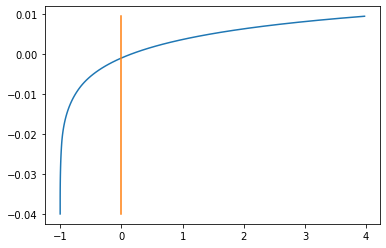

In [276]:
# Plot to see visually where the steady state is
cut =  10
cut = len(rs)
plt.plot(As[0:cut],rs[0:cut])
plt.plot(np.zeros(len(rs[0:cut])),rs[0:cut])
plt.show()


Recall, in the steady state, aggregating budget constraints 

$$ C = r A + Y \rightarrow C = Y \iff A = 0$$ 

**Solving for the Steady State via Numerical Root Finding** 

We are essentially trying to clear a single excess demand equation in the steady state; we just need to find it's root, which is not easy since $A(\cdot)$ is highly non-linear. 

$$ H(x) = A(r^{ss}) = 0$$

Which you need to define in Python speak as, for example, a function `Hss` that takes any `x`, uses it as the interest rate, and finds the value of `A(x)` in the graph above. We want to find the `x` that makes that function 0.

Please read the following QuantEcon resource on root finding. 

https://python-programming.quantecon.org/scipy.html

Historically, there were two alternative ways to find $x_0$ that clears $f(x) = 0$: bisection and quasi-Newton based methods. Bisection based methods are messier (and slower) to write but more reliable since they can more easily avoid trouble. Quasi-Newton methods are faster and easier to implement numerically, but can often have trouble finding a solution. We will see more about Newton next week, since our alternative to bisection-based shooting algorithms is a Newton-based algorithm uses Jacobians to find IRFs. Modern day root finding uses a hybrid of Newton and bisection. `ScyPy`'s `brentq` optimization and root/finding function implements such hybrid method.

`r, sol = opt.brentq(lambda x : Hss(x), rmin, rmax, full_output=True)`

Like Newton, it does require a guess and involves a Jacobian updating from the secant line (again, we will cover this next week).

$$ x_1 = x_0 - J^{-1} f(x_0) $$ 

Like bisection, it requires two bounds, `rmin, rmax`, which should hold the solution in between if you specify them well. Above I gave you two examples of these two bounds in my case, each delivering an $A$ to both sides of 0. 

In [281]:
# Pseudo code:

# Steady state r solver given Y = 1: Create a market clearing function for excess demand/supply 

# Hss = ... # define H

# rmax = rs[-1] # Get bounds for guess
# rmin = rs[0]

# assert((Hss(rmax) > 0 & 0 >  Hss(rmin) ) | (Hss(rmax) < 0 & 0 <  Hss(rmin))) # make sure it brackets solution

# r, sol =... # use brentq as described above

# rss = r
# ss0 = ... # solve for SS values using ss at rss

# D = ...
# a = ...
# c = ...

# print('General Equilibrium Interest Rate = ', 100*4*round(r,4), '% (Annual)')


General Equilibrium Interest Rate =  -0.4 % (Annual)


A =  1.5650148732504476e-08
C =  1.0000000010032088
sum D =  1.0000000000000038
CDF(a) of stationary distribution D with dimensions:  (7, 500)


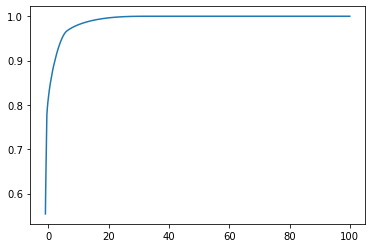

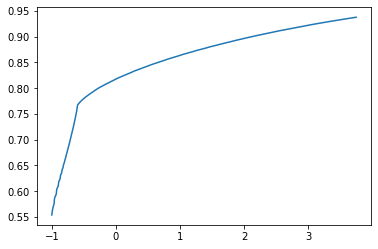

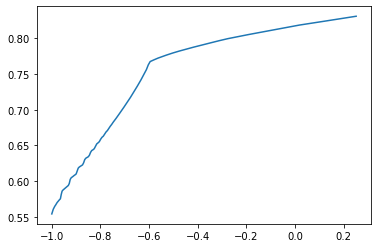

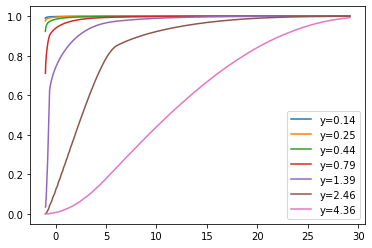

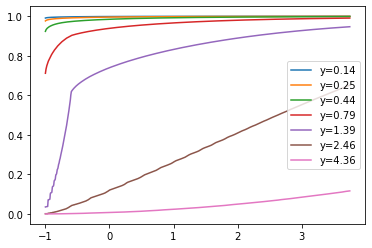

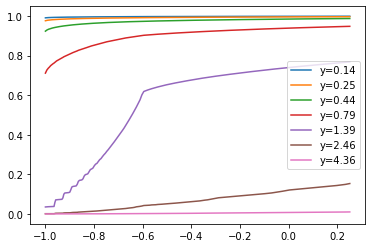

In [283]:
# Aggregate using the stationary distribution 

A = np.vdot(D, a)
C = np.vdot(D, c)

print('A = ', A)
print('C = ', C)

print('sum D = ', np.sum(np.sum(D)))

D = forward_ss(param,r,Y)
print('CDF(a) of stationary distribution D with dimensions: ', D.shape )
plt.plot(a_grid, D.sum(axis=0).cumsum())
plt.show()
plt.plot(a_grid[0:250], D.sum(axis=0)[0:250].cumsum());
plt.show()
plt.plot(a_grid[0:150], D.sum(axis=0)[0:150].cumsum());
plt.show()

for s, y in enumerate(s_grid):
    plt.plot(a_grid[:400], D[s][:400].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

for s, y in enumerate(s_grid):
    plt.plot(a_grid[:250], D[s][:250].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

for s, y in enumerate(s_grid):
    plt.plot(a_grid[:150], D[s][:150].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend();
plt.show()

**General Equilibrium Transition Dynamics**

We are going to be exploiting perfect-foresight after an MIT shock found via a *bisection-based* shooting algorithm. 

**Important** If you manage to learn how to do all the stuff I did until now, but you can't quite do this last part, it's OK! Shooting algorithms are hard and unreliable. We'll be learning "easier" but clever alternatives throughout the course that use sequence-space Jacobians rather than ad-hoc rules.

If you want a good example of a paper using shooting, look at Guerrieri-Lorenzoni in the Syllabus.

Assume the economy starts out from the steady state $Y=1$ and gets a shock sequence starting at $t=1$

$$ Y_{t}=Y+d Y \cdot \eta^{t} $$

Let $d Y=0.1 \text { and } \eta=0.90 $

Starting from $r_0$, we want to find a *sequence* of forward looking interest rates $\{r_t\}_{t = 1,....,T}$ such that asset markets clear in every period: $A_{t}=0$. 

The most important thing to tackle this is to get the timing just right.

Recall that 

\begin{array}{c}
V_{t}\left(s_{t}, a_{t-1}\right)=\max _{a_{t} \geq \underline{a}}\left\{u\left(c_{t}\right)+\beta \mathbb{E}_{t}\left[V_{t+1}\left(s_{t+1}, a_{t}\right) \mid s_{t}\right]\right\} \\
c_{t}=\left(1+r_{t-1}\right) a_{t-1}-a_{t}+s_{t} Y_{t}
\end{array}

So that the problem of the agent depended on the *entire sequence* of output and prices.

$$V_{t}\left(s_{t}, a_{t-1}\right)=V\left(s_{t}, a_{t-1} ;\left\{r_{\tau-1}, Y_{\tau}\right\}_{\tau=t}^{\infty}\right) \equiv V\left(s, a_{-} ; \mathbf{r}_{-}, \mathbf{Y}\right)$$


Thus, our FOC, Euler, budget constraint, and the borrowing constraint imply a policy function of the form 

$$ a_{t}\left(\left\{r_{\tau-1}, Y_{\tau}\right\}_{\tau=t}^{\infty}\right) $$ 

Where the dependence on current and future aggregates come from current $DI_t = \left(1+r_{t-1}\right) a_{t-1}+ s_{t} Y_{t}$ and $c_t = DI_t - a_t$ and future ones come from the Euler, which features $r_t$, and $c_{t+1} = DI_{t+1} - a_{t+1}$ and so on.

$$ u^{\prime}\left(c_{t}\right) \geq \beta \mathbb{E}_{t}\left[\frac{\partial V_{t+1}}{\partial a_{t}}\left(s_{t+1}, a_{t}\right) \mid s_{t}\right], \quad \text { with equality } \operatorname{iff} a_{t}>\underline{a}, \quad \frac{\partial V_{t}}{\partial a_{t-1}}\left(s_{t}, a_{t-1}\right)=u^{\prime}\left(c_{t}\right)\left(1+r_{t-1}\right)$$ 

We then proceed with backward and forward iteration as we did above. I have an appendix with some notes on distributional dynamics along transitions if you need more help. You can also look at the last slide in section 1. 

**Shooting Algorithm Steps**

1. *Guess interest rate path* Guess a candidate *path* for interest rates: $\left\{r_{t}\right\}$, starting from $r_0$, with a shock in $r_1$, and eventually converging back to $r_T=r_0$ for some large $T$, which we have in memory. In memory we also have $V_{a,{T}} = V_a$ at the very last period where we impose that $V_a(r,Y)$ is back in the steady state.   One naive guess is to assume the path is flat. Another is to exploit our economic intuition about the problem. 

2. *Backward iterate from terminal steady state V* Given our guessed path for endogenous aggregate $r_t$ and the exogenous path of the shock $Y_t$, solve for each period's policy function by iterating backwards starting from a large $T$, assuming that $\frac{\partial V_{T+1}}{\partial a_{T}} = V_a(r,Y)$ is back to it's steady state value stored. Find the sequence $\mathbf{c}_{t}^{*}, \mathbf{a}_{t}^{*}$ of arrays. 

3. *Forward iterate from terminal steady state D*. Start from the steady state distribution $D_{-1}$ at time $t=0$, and apply forward iteration to arrive to a sequence of $\{D_{t}\}$ distribution matrices.

4. *Compute sequences of excess demands* by looking computing sequences $\left\{H_t\right\} = \left\{A_{t}\right\} - 0$ with have in each period the aggregate savings: $A_t = \sum \sum a D_t(s,a)$ 

5. *Adjust prices to clear markets in all periods* by adjusting the *entire path* of $\left\{r_{t}\right\}$ using for example 

$$\mathbf{r}^1 = (1-\theta) \mathbf{r}^0 - \theta \mathbf{H}(\mathbf{r}^0) $$

That is, if savings are too high, and we want households to save less (borrow more), lower $r$. This ensures that if there's too little savings $H<0$, you make it more attractive for households to save by increasing $r$. 

Note: pick $\theta$ **very** small and update "gently". If you pick $\theta$ too large, you'll be horrified how fast distance can converge to $\infty$.


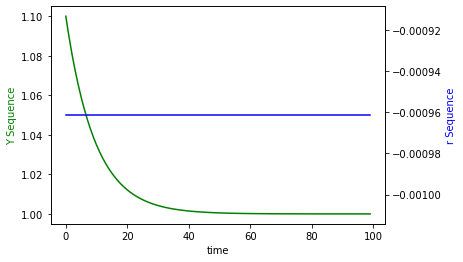

In [25]:
#### Y = 1
T = 100
η = 0.9
dY  = 0.1
time = np.arange(T)
Y_t   = Y + dY*η**time
Y_t

#More income will push people out of the constraint, and increase savings demand, hence, increase r with Y

θ = 0.5

# Initialize
r_t = rss*np.ones_like(time)  # this is just a guess

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(time, Y_t, 'g-')
ax2.plot(time, r_t, 'b-')

ax1.set_xlabel('time')
ax1.set_ylabel('Y Sequence', color='g')
ax2.set_ylabel('r Sequence', color='b')

plt.show()



In [284]:
# Shooting pseudo-code

#@jit
# def shooting_algorithm(T, η, dY, θ, param):
#     ... # unpack params

#     #Initialize Sequences
#     rss = ss0['r'] # ... get steady states
#     Y   = ss0['Y']
#     Y_t   = ... # build exogenous path 
#     r_t   = ... # make a guess for the path of r (e.g. constant at rss)

#     Va_t   = .... # get blank sequences of matrices to store your results
#     ...    
            
#     for it in range(0,shooting_maxit):
#         Va_t[:,:,-1] = ... # initialize at the last steady state/period
#         D_t[:,:,0]   = ... # initialize at the first steady state/period

#         # # try to add @jit decorator here to speed up the loops via vectorization

#         #print('Starting Backward Iteration')  
#         for t in range(1,T): 

#             Va_t[:,:,-t], a_t[:,:,-t] , _ = ... # DO BACKWARD ITERATION

#             x_i_t[:,:,-t], x_pi_t[:,:,-t] = ... # MAP POLICIES OFF GRID ONTO GRID

#         #print('Starting Forward Iteration') 
#         for t in range(1,T): 

#             D_t[:,:,t] = ... # DO FORWARD ITERATION    

#             A_t[t]     = ... # GEN SEQUENCES OF AGGREGATE SAVINGS TO CLEAR 
          
          #print('Update Sequence') 
        
#         r_t[1:T] = ... # use small θ to SHRINK GENTLY! 

#         distance = np.linalg.norm(A_t[1:T] - 0)
#         ...



In [ ]:
plt.plot(np.arange(len(param['r_t'])),(r_t - rss)/rss)
plt.plot(np.arange(len(param['A_t'])),np.zeros(len(param['A_t'])),'k-')

Numba is to Python what Mex is to MATLAB: hitting the "turbo" button. 

It does this by inferring type information on the fly.

## Appendix: Distributional Dynamics out of the Steady State

In general, in a transition, we will have to find a path of the distribution forward given the choices made iterating backwards (now value and policy functions depend on $t$ via the path of $r_{t-1}$ and $Y_t$). 

$$ D_{t}\left(s^{\prime}, \mathcal{A}\right)=\sum_{s} \pi_{s^{\prime} s} D_{t-1}\left(s, a_{t-1}^{*}(s, \cdot)^{-1}(\mathcal{A})\right)$$

$$ V_{t}\left(s, a_{-}\right)=\max _{a \geq a}\left\{u\left(\left(1+r_{t-1}\right) a_{-}-a+s Y_{t}\right)+\beta \mathbb{E}_{t}\left[V_{t+1}\left(s^{\prime}, a\right) \mid s\right]\right\} $$

and calculate aggregates at each point in time

$$ A_{t}=\sum_{s} p_{s} \int a_{t}^{*}\left(s, a_{-}\right) D_{t}\left(s, d a_{-}\right) \quad C_{t}=\sum_{s} p_{s} \int c_{t}^{*}\left(s, a_{-}\right) D_{t}\left(s, d a_{-}\right)$$

In general, what you should remember are the following two identities, which can help you think through the distribution dynamics (note there might have been an error in the last slide of lecture 1 if you downloaded an earlier version).

$$ \int \int a_{-} D_{t+1}(s,a_{-}) =  A_t = \int \int a_t(s,a_{-}) D_{t}(s,a_{-})$$ 

This means that  

$$ A_{t-1} = \int \int a_{-} D_t(s,a_{-}),\quad\quad A_t = \int \int a_t(s,a_{-}) D_{t}(s,a_{-})  $$ 

Note that in the steady state (and in transition in models when $A=0$), these two objects should be the same no matter how you define them. However, in models with firms providing capital (as in Krusell Smith) or governments providing bonds for households to save on (as in Guerrieri-Lorenzoni), these two objects will differ in transition.

## Optional Appendix: Young-Alternatives using Winberry's Semi-Parametric Methods


As a semi-parametric alternative to Young's histogram method, Winberry (2018) proposes a multivariate version of Algan, Allais, and Haan (2008) let's $D\left(s, a_{-}\right) = g(\varepsilon,k)$

$$ \begin{aligned}
g(s, a) \approx & g_{0} \exp \left\{g_{1}^{1}\left(s-m_{1}^{1}\right)+g_{1}^{2}\left(\log a_{-}-m_{1}^{2}\right)\right. \left.+\sum_{i=2}^{n_{g}} \sum_{j=0}^{i} g_{i}^{j}\left[\left(s-m_{1}^{1}\right)^{i-j}\left(\log a_{-}-m_{1}^{2}\right)^{j}-m_{i}^{j}\right]\right\}
\end{aligned}$$ 

where $n_g$ indexes the degree of approximation, $g_{0}, g_{1}^{1}, g_{1}^{2},\left\{g_{i}^{j}\right\}_{i, j=(2,0)}^{\left(n_{g}, i\right)}$ are parameters, and $m_{1}^{1}, m_{1}^{2},\left\{m_{i}^{j}\right\}_{i, j=(2,0)}^{\left(n_{g}, i\right)}$ are centralized moments of the distribution.

Note: a $n_{g}=2$ in this family corresponds to a multi-variate normal distribution, while higher degrees allows for skewness and kurtosis. 



The parameters $\mathbf{g}=\left(g_{0}, \ldots, g_{n_{g}}^{n_{g}}\right)$ and moments $\mathbf{m}=\left(m_{1}^{1}, \ldots, m_{n_{g}}^{n_{g}}\right)$ must be consistent with each other  in the sense that the moments are actually implied by the parameters:

$$
m_{1}^{1}=\iint s g(s, a_{-}) d s d a_{-} 
\\
m_{1}^{2}=\iint \log a_{-} g(s, a_{-}) d s d a_{-} 
\\
 m_{i}^{j}=\iint\left(s-m_{1}^{1}\right)^{i-j}\left(\log a_{-} - m_{1}^{2}\right)^{j} g(s, a_{-}) d s d a_{-}
\\ \text { for } i=2, \ldots, n_{g}, j=0, \ldots, i
$$ 

Hence, the vector of moments $\mathbf{m}$ fully characterizes the density. In the normal case, all we need is a couple. Winberry essentially iterates on parameters $g$ to try to match moments $m$, taking as a guess the histogram resulting from Young's method.

If you want to read more about this, check out the paper

https://qeconomics.org/ojs/index.php/qe/article/viewFile/617/609